<a href="https://colab.research.google.com/github/wunann03/AmplifAi-Bootcamp-Basics-of-Neural-Networks/blob/CNN/Alexnet_Classification_TL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[Roboflow link](https://app.roboflow.com/sushicnn/projects)

In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="nz4SpWfRZYvZWZUiNLsp")
project = rf.workspace("sushicnn").project("sushi-cnn")
version = project.version(1)
dataset = version.download("folder")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 60.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Sushi---CNN-1 in folder:: 100%|██████████| 161/161 [00:00<00:00, 6363.33it/s]


In [2]:
!pip install torch torchvision

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision import models
import numpy as np
import matplotlib.pyplot as plt
import os
import random

# Seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Determine the device to use
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {device}")

Running on device: cuda:0


In [4]:
# Define transformations
# Common standard mean and standard deviation for image normalization
# Resizing to 224x224 is standard for pre-trained models like AlexNet
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# Define transformations
transform = transforms.Compose([
    # Resize to 224x224, which is the standard input size for pre-trained AlexNet
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # Normalize the tensor images
    transforms.Normalize(mean=MEAN, std=STD)
])

DATA_ROOT = '/content/Sushi---CNN-1'

# 1. Create Image Datasets
try:
    # torchvision.datasets.ImageFolder automatically assigns labels based on folder names
    train_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, 'train'), transform=transform)
    test_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, 'test'), transform=transform)

    # Print class mapping
    print("Class mapping:", train_dataset.class_to_idx)

    # 2. Create Data Loaders
    BATCH_SIZE = 32
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    print(f"Loaded {len(train_dataset)} training images and {len(test_dataset)} testing images.")

except Exception as e:
    print(f"Failed to Load Data! Error: {e}")


Class mapping: {'NASI LEMAK': 0, 'SUSHI': 1}
Loaded 132 training images and 6 testing images.


In [7]:
def create_transfer_alexnet(num_classes=2):
    """
    Loads a pre-trained AlexNet model and adapts it for our 2-class task.
    """
    # Load the AlexNet pre-trained on ImageNet. This model has already learned
    # useful features from millions of images.
    # 'weights=models.AlexNet_Weights.IMAGENET1K_V1' ensures the pre-trained weights are used.
    model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)

    # 1. Freeze the feature extraction layers (convolutional layers)
    # By setting requires_grad=False, we tell PyTorch not to calculate gradients
    # for these parameters, keeping the pre-trained features intact.
    for param in model.features.parameters(): # Correctly call the method to get parameters
        param.requires_grad = False
    #

    # 2. Modify the classifier layers for our specific two classes.
    # The AlexNet classifier is a sequential block of fully connected layers.
    # We only need to change the final layer (index 6).

    # Get the number of input features of the last original layer
    num_ftrs = model.classifier[6].in_features

    # Replace the last layer (index 6) with a new Linear layer
    # that outputs the correct number of classes (2 in our case).
    model.classifier[6] = nn.Linear(num_ftrs, num_classes)

    return model

In [8]:
## 4. Loss Function and Optimizer
# Instantiate the model and move it to the device (CPU/GPU)
model = create_transfer_alexnet(num_classes=2).to(device)
print(model)

#We use CrossEntropyLoss, which is standard for multi-class classification and combines `LogSoftmax` and `NLLLoss` for better numerical stability.
# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [9]:
## 5. Training Function

#This function iterates through the dataset for a specified number of epochs.

def train_model(model, train_loader, criterion, optimizer, num_epochs=10):
    model.train() # Set the model to training mode

    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for i, (inputs, labels) in enumerate(train_loader):
            # Move data to the selected device
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            # Statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total

        print(f'Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.8f} | Accuracy: {epoch_acc:.2f}%')

    print('Finished Training.')
    return model


NUM_EPOCHS = 100
# Start training
trained_model = train_model(model, train_loader, criterion, optimizer, num_epochs=NUM_EPOCHS)


Epoch 1/100 | Loss: 0.69450928 | Accuracy: 69.70%
Epoch 2/100 | Loss: 0.03662877 | Accuracy: 98.48%
Epoch 3/100 | Loss: 0.00289730 | Accuracy: 100.00%
Epoch 4/100 | Loss: 0.04719814 | Accuracy: 97.73%
Epoch 5/100 | Loss: 0.85687849 | Accuracy: 95.45%
Epoch 6/100 | Loss: 0.57205345 | Accuracy: 97.73%
Epoch 7/100 | Loss: 1.70232845 | Accuracy: 95.45%
Epoch 8/100 | Loss: 2.35444146 | Accuracy: 93.94%
Epoch 9/100 | Loss: 9.04581811 | Accuracy: 84.09%
Epoch 10/100 | Loss: 7.02459316 | Accuracy: 86.36%
Epoch 11/100 | Loss: 2.82812152 | Accuracy: 95.45%
Epoch 12/100 | Loss: 0.06633888 | Accuracy: 99.24%
Epoch 13/100 | Loss: 0.00000000 | Accuracy: 100.00%
Epoch 14/100 | Loss: 0.01230857 | Accuracy: 99.24%
Epoch 15/100 | Loss: 0.00000000 | Accuracy: 100.00%
Epoch 16/100 | Loss: 0.00000000 | Accuracy: 100.00%
Epoch 17/100 | Loss: 0.00000000 | Accuracy: 100.00%
Epoch 18/100 | Loss: 0.00000000 | Accuracy: 100.00%
Epoch 19/100 | Loss: 0.00000000 | Accuracy: 100.00%
Epoch 20/100 | Loss: 0.00000000 |

In [10]:
def test_model(model, test_loader):
    model.eval() # Set the model to evaluation mode
    correct = 0
    total = 0

    with torch.no_grad(): # Disable gradient calculation for inference
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            # Get the predicted class (index of the max log-probability)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'\nModel Accuracy on Test Set: {accuracy:.2f}% ({correct}/{total})')

# Test the final model
test_model(trained_model, test_loader)



Model Accuracy on Test Set: 83.33% (5/6)


--------------------------------------------------
Selected Image Index: 1
True Label: NASI LEMAK
Predicted Label: NASI LEMAK
--------------------------------------------------


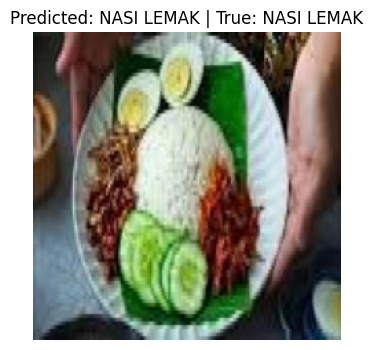

In [16]:
def unnormalize_tensor(tensor, mean, std):
    """Reverses the normalization for plotting."""
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor


def predict_example_image(model, dataset):

    model.eval()
    # 1. Select a random image index
    random_index = random.randint(0, len(dataset) - 1)

    # 2. Get the image tensor and true label
    image_tensor, true_label = dataset[random_index]

    # 3. Prepare image for model (add batch dimension and move to device)
    input_tensor = image_tensor.unsqueeze(0).to(device)

    # 4. Run inference
    with torch.no_grad():
        output = model(input_tensor)
        # Get the predicted class index
        _, predicted_index = torch.max(output, 1)

    # 5. Get the class names
    classes = dataset.classes
    true_class = classes[true_label]
    predicted_class = classes[predicted_index.item()]

    # 6. Display the result
    print("-" * 50)
    print(f"Selected Image Index: {random_index}")
    print(f"True Label: {true_class.upper()}")
    print(f"Predicted Label: {predicted_class.upper()}")
    print("-" * 50)

    # 7. Plot the image
    # Clone and unnormalize the tensor for visualization
    img_for_plot = image_tensor.clone().cpu()
    unnormalize_tensor(img_for_plot, MEAN, STD)

    # PyTorch tensors are (C, H, W), Matplotlib needs (H, W, C)
    npimg = img_for_plot.numpy()
    plt.figure(figsize=(4, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(f"Predicted: {predicted_class.upper()} | True: {true_class.upper()}")
    plt.axis('off')
    plt.show()

# Run the prediction on a random sample from the test set
predict_example_image(trained_model, test_dataset)